Duplicate columns found: Index([], dtype='object')
Duplicates removed. Columns now: 32
Filtered last 10 years. Shape: (4698, 32)


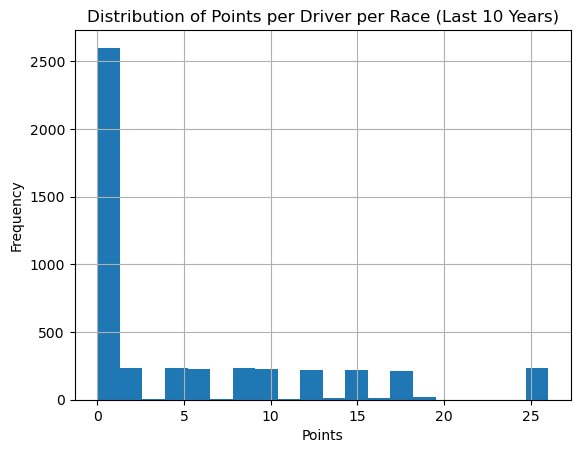

DNF Counts:
 dnf
0    4057
1     641
Name: count, dtype: int64


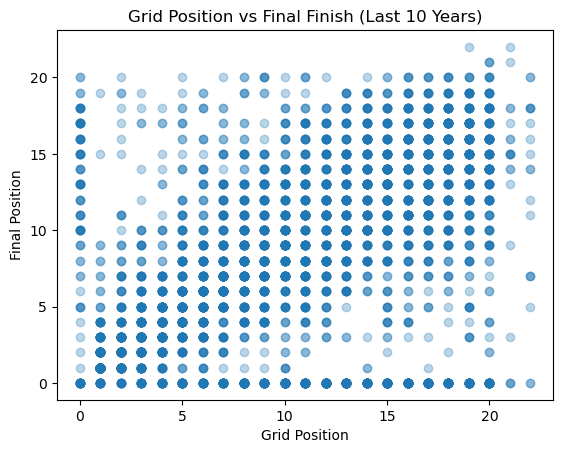

Correlation matrix:
               grid  position    points      laps       dnf
grid      1.000000  0.482337 -0.623045 -0.074045  0.083265
position  0.482337  1.000000 -0.547508  0.327079 -0.551361
points   -0.623045 -0.547508  1.000000  0.239899 -0.277736
laps     -0.074045  0.327079  0.239899  1.000000 -0.708261
dnf       0.083265 -0.551361 -0.277736 -0.708261  1.000000
Top 10 Drivers:
 driver_name
Lewis Hamilton      3469.5
Max Verstappen      3301.5
Valtteri Bottas     1598.0
Charles Leclerc     1588.0
Sebastian Vettel    1480.0
Sergio Pérez        1397.0
Lando Norris        1344.0
Carlos Sainz        1257.5
Daniel Ricciardo    1052.0
George Russell       953.0
Name: points, dtype: float64
Top 10 Constructors:
 name_constructor
Mercedes          6433.5
Red Bull          5217.5
Ferrari           4713.5
McLaren           2616.0
Williams           684.0
Force India        607.0
Aston Martin       572.0
Alpine F1 Team     518.0
Renault            459.0
Haas F1 Team       366.0
Name: po

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(
    "C:/Users/LENOVO/Desktop/Kavi docu/jobs/f1-business-analytics/data/processed/f1_clean_analytics_dataset.csv",
    dtype={'number': 'string'},
    low_memory=False
)

# -----------------------------
# Handle duplicate columns
# -----------------------------
duplicates = df.columns[df.columns.duplicated()].unique()
print("Duplicate columns found:", duplicates)

# Keep only first occurrence of each column
df = df.loc[:, ~df.columns.duplicated()]
print("Duplicates removed. Columns now:", df.shape[1])

# -----------------------------
# Filter last 10 years
# -----------------------------
latest_year = df['year'].max()
start_year = latest_year - 10
df_recent = df[df['year'] >= start_year].copy()
print("Filtered last 10 years. Shape:", df_recent.shape)

# -----------------------------
# Basic EDA
# -----------------------------
# Points distribution
df_recent['points'].hist(bins=20)
plt.title("Distribution of Points per Driver per Race (Last 10 Years)")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

# DNF distribution
print("DNF Counts:\n", df_recent['dnf'].value_counts())

# Grid vs Final Position
plt.scatter(df_recent['grid'], df_recent['position'], alpha=0.3)
plt.xlabel("Grid Position")
plt.ylabel("Final Position")
plt.title("Grid Position vs Final Finish (Last 10 Years)")
plt.show()

# Correlation
corr = df_recent[['grid', 'position', 'points', 'laps', 'dnf']].corr()
print("Correlation matrix:\n", corr)

# Top Drivers & Constructors
top_drivers = df_recent.groupby('driver_name')['points'].sum().sort_values(ascending=False).head(10)
top_constructors = df_recent.groupby('name_constructor')['points'].sum().sort_values(ascending=False).head(10)
print("Top 10 Drivers:\n", top_drivers)
print("Top 10 Constructors:\n", top_constructors)

# -----------------------------
# Feature Engineering - Drivers
# -----------------------------
driver_features = (
    df_recent.groupby('driver_name')
    .agg(
        races=('raceId', 'count'),
        total_points=('points', 'sum'),
        avg_points=('points', 'mean'),
        points_std=('points', 'std'),
        avg_grid=('grid', 'mean'),
        avg_finish=('position', 'mean'),
        dnf_rate=('dnf', 'mean'),
        avg_grid_vs_finish=('grid_vs_finish', 'mean')
    )
    .reset_index()
)

# Derived metrics
driver_features['consistency_index'] = driver_features['avg_points'] / (driver_features['points_std'] + 1)
driver_features['efficiency_score'] = driver_features['avg_points'] / (driver_features['avg_grid'] + 1)

# Min-max normalization function
def min_max(s):
    return (s - s.min()) / (s.max() - s.min())

# Composite scores
driver_features['performance_index'] = (
    0.5 * min_max(driver_features['avg_points']) +
    0.3 * (1 - driver_features['dnf_rate']) +
    0.2 * min_max(driver_features['avg_grid_vs_finish'])
)
driver_features['roi_proxy'] = driver_features['total_points'] / (driver_features['races'] + 1)
driver_features['performance_volatility'] = driver_features['points_std'].fillna(0)

# Flags
high_perf_threshold = driver_features['avg_points'].quantile(0.75)
driver_features['high_performer_flag'] = (driver_features['avg_points'] >= high_perf_threshold).astype(int)
driver_features['reliable_driver_flag'] = (
    (driver_features['dnf_rate'] < driver_features['dnf_rate'].median()) &
    (driver_features['consistency_index'] > driver_features['consistency_index'].median())
).astype(int)

# -----------------------------
# Feature Engineering - Constructors
# -----------------------------
constructor_features = (
    df_recent.groupby('name_constructor')
    .agg(
        races=('raceId', 'count'),
        total_points=('points', 'sum'),
        avg_points=('points', 'mean'),
        dnf_rate=('dnf', 'mean')
    )
    .reset_index()
)

constructor_features['performance_index'] = min_max(constructor_features['avg_points'])

# -----------------------------
# Save cleaned & engineered data to CSV for SQL Server
# -----------------------------
driver_features.to_csv("driver_features.csv", index=False)
constructor_features.to_csv("constructor_features.csv", index=False)
df_recent.to_csv("f1_recent_10yrs.csv", index=False)


